# Análise - Pilotos que mais ganham ou perdem posições entre largada e chegada

##  1. Introdução

Na Fórmula 1, a habilidade de manter ou melhorar a posição após a largada é um dos principais indicadores de performance e consistência dos pilotos. Esta análise visa identificar os pilotos que mais ganham ou perdem posições entre a largada e a chegada, considerando dados históricos.

## 2. Objetivo

Os objetivos principais desta Análise Exploratória de Dados (EDA) são:

    - Calcular a diferença entre a posição de largada (obtida no qualifying) e a posição final (resultado da corrida) para cada piloto.

    - Identificar os pilotos que:

    - Mais perdem posições largando entre os 5 primeiros;

    - Mais ganham posições largando atrás da 10ª posição.

## 3. Metodologia
Inicialmente, foram utilizadas três bases de dados principais:

    - qualifying.csv: Contém as posições de largada dos pilotos, baseadas no treino classificatório;

    - results.csv: Apresenta os resultados finais de cada corrida (posição de chegada real);

    - drivers.csv: Informações dos pilotos, como nome e identificação.

#### 3.1 Carregamento, Filtragem e Pré-processamento dos Dados

In [2]:
import pandas as pd

# Carregamento dos dados
qualifying = pd.read_csv("qualifying.csv")
results = pd.read_csv("results.csv")
drivers = pd.read_csv("drivers.csv")

# Filtrando colunas relevantes
qualifying = qualifying[["raceId", "driverId", "position"]].rename(columns={"position": "qualifying_position"})
results = results[["raceId", "driverId", "positionOrder"]]

# Unindo dados de largada e chegada
df = pd.merge(qualifying, results, on=["raceId", "driverId"], how="inner")

# Cálculo da diferença de posições (largada - chegada)
df["position_diff"] = df["qualifying_position"] - df["positionOrder"]

# Incluindo nomes completos dos pilotos
drivers["driver_name"] = drivers["forename"] + " " + drivers["surname"]
df = pd.merge(df, drivers[["driverId", "driver_name"]], on="driverId", how="left")

# Filtragem: pilotos que largaram no Top 5 e perderam posições
lost_positions_early = df[(df["qualifying_position"] <= 5) & (df["position_diff"] < 0)]

# Filtragem: pilotos que largaram após o 10º e ganharam posições
gained_positions_late = df[(df["qualifying_position"] > 10) & (df["position_diff"] > 0)]

# Resultados: média de posições perdidas ou ganhas
print("Top 10 pilotos que mais perdem posições largando no Top 5:")
print(lost_positions_early.groupby("driver_name")["position_diff"].mean().nsmallest(10))

print("\nTop 10 pilotos que mais ganham posições largando atrás do 10º:")
print(gained_positions_late.groupby("driver_name")["position_diff"].mean().nlargest(10))


Top 10 pilotos que mais perdem posições largando no Top 5:
driver_name
Ayrton Senna         -18.666667
Nigel Mansell        -14.500000
Ukyo Katayama        -14.500000
Sébastien Bourdais   -14.000000
Jyrki Järvilehto     -13.500000
Mika Häkkinen        -12.071429
Pastor Maldonado     -11.750000
Jean Alesi           -11.444444
Gerhard Berger       -11.000000
Guanyu Zhou          -11.000000
Name: position_diff, dtype: float64

Top 10 pilotos que mais ganham posições largando atrás do 10º:
driver_name
Roland Ratzenberger    15.000000
Allan McNish           12.000000
Jean-Marc Gounon       11.000000
Jyrki Järvilehto       10.666667
Érik Comas             10.250000
Tarso Marques          10.000000
Max Verstappen          9.714286
Olivier Beretta         9.500000
Juan Pablo Montoya      9.400000
David Brabham           8.733333
Name: position_diff, dtype: float64


## 4. Conclusão

A análise realizada sobre a variação das posições entre a largada e a chegada das corridas evidenciou pontos importantes sobre o desempenho dos pilotos na Fórmula 1:

    - Pilotos que largam entre os 5 primeiros e perdem posições demonstram que manter a posição na frente do grid nem sempre é garantia de um bom resultado final, refletindo fatores como pressão da corrida, estratégias e adversidades.

    - Já os pilotos que largam atrás da 10ª posição e conseguem ganhar posições mostram habilidade e agressividade para ultrapassar, além de estratégias eficazes que lhes permitem recuperar terreno durante a prova.

    - Os gráficos destacam claramente os pilotos que mais sofrem perdas e os que mais ganham posições, oferecendo um panorama da dinâmica de cada perfil dentro das corridas.

/var/folders/5z/p9vk7tg12wq_vpmfx1kgwpg40000gn/T/ipykernel_3433/1514832852.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lost_positions_avg.values, y=lost_positions_avg.index, palette="Reds_r")


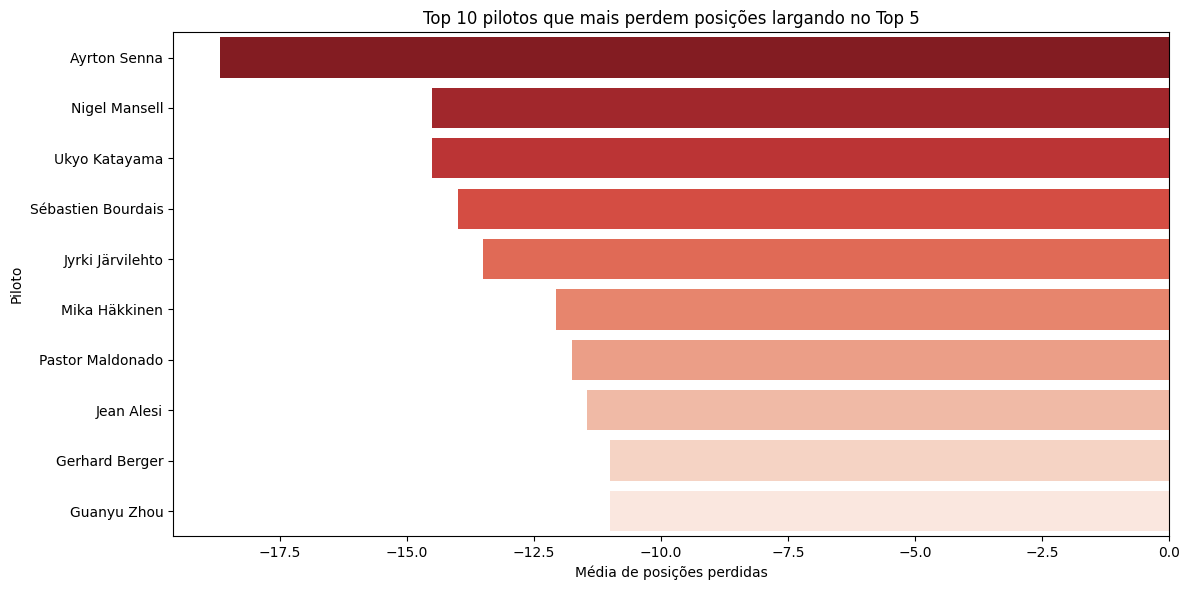

/var/folders/5z/p9vk7tg12wq_vpmfx1kgwpg40000gn/T/ipykernel_3433/1514832852.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gained_positions_avg.values, y=gained_positions_avg.index, palette="Greens")


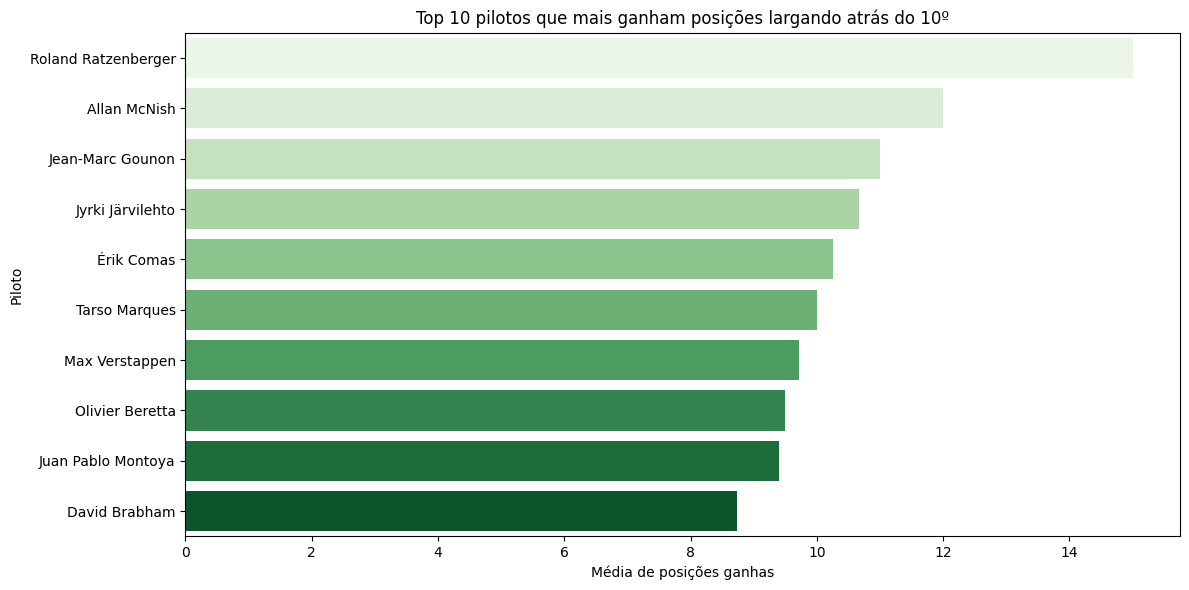

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np

# Carregamento dos dados
qualifying = pd.read_csv("qualifying.csv")
results = pd.read_csv("results.csv")
drivers = pd.read_csv("drivers.csv")

# Filtrando colunas relevantes
qualifying = qualifying[["raceId", "driverId", "position"]].rename(columns={"position": "qualifying_position"})
results = results[["raceId", "driverId", "positionOrder"]]

# Unindo dados de largada e chegada
df = pd.merge(qualifying, results, on=["raceId", "driverId"], how="inner")

# Cálculo da diferença de posições (largada - chegada)
df["position_diff"] = df["qualifying_position"] - df["positionOrder"]

# Incluindo nomes completos dos pilotos
drivers["driver_name"] = drivers["forename"] + " " + drivers["surname"]
df = pd.merge(df, drivers[["driverId", "driver_name"]], on="driverId", how="left")

# Filtragem: pilotos que largaram no Top 5 e perderam posições
lost_positions_early = df[(df["qualifying_position"] <= 5) & (df["position_diff"] < 0)]

# Filtragem: pilotos que largaram após o 10º e ganharam posições
gained_positions_late = df[(df["qualifying_position"] > 10) & (df["position_diff"] > 0)]

# Média de posições perdidas ou ganhas por piloto
lost_positions_avg = lost_positions_early.groupby("driver_name")["position_diff"].mean().nsmallest(10)
gained_positions_avg = gained_positions_late.groupby("driver_name")["position_diff"].mean().nlargest(10)

# Plot: Top 10 pilotos que mais perdem posições largando no Top 5
plt.figure(figsize=(12,6))
sns.barplot(x=lost_positions_avg.values, y=lost_positions_avg.index, palette="Reds_r")
plt.title("Top 10 pilotos que mais perdem posições largando no Top 5")
plt.xlabel("Média de posições perdidas")
plt.ylabel("Piloto")
plt.tight_layout()
plt.show()

# Plot: Top 10 pilotos que mais ganham posições largando atrás do 10º
plt.figure(figsize=(12,6))
sns.barplot(x=gained_positions_avg.values, y=gained_positions_avg.index, palette="Greens")
plt.title("Top 10 pilotos que mais ganham posições largando atrás do 10º")
plt.xlabel("Média de posições ganhas")
plt.ylabel("Piloto")
plt.tight_layout()
plt.show()
